# Preprocessing

Set PATH for package imports

In [10]:
import os
import sys

# Go up THREE levels (project root directory)
project_root = os.path.dirname(os.path.dirname(os.getcwd()))
# Append the new path to sys.path
if project_root not in sys.path:
    sys.path.append(project_root)
    print("Project root added to sys.path")
else:
    print("Project root already in sys.path")

Project root already in sys.path


Processing `npt-HK4.gro` file into pandas dataframe

In [6]:
from utils import gro_processing as gp

# Data directory can be accessed due to root PATH we set previously
path = 'data/npt-HK4.gro'
abs_path = os.path.join(project_root, path)

# Extracts data from .gro file into multi-index DataFrame (unsorted)
df_gro, title, num_atoms, box_dimensions = gp.read_gro(abs_path, multiply=10, positions=True, velocities=False) # convert nm to Å  
    
# Checking
# df_gro

# Generating Molecule Meshes

Create `mol_meshes` dictionary, which contains 1501 individual molecule mesh. (i.e. `{1: mesh1, 2: mesh2, ... 1501: mesh1501}`)

In [3]:
from utils.generate_mol_meshes import molecules_to_meshes

mol_meshes = molecules_to_meshes(df_gro, box_dimensions, 
                                 sphere_radius_scale=0.8, 
                                 sphere_subdiv=2, 
                                 bond_radius=0.1,
                                 num_processes=None, context='fork')
print(len(mol_meshes))        # 1501
print(mol_meshes[1])          # trimesh.Trimesh object

Processing 1501 molecules with 8 logical cores: 100%|██████████| 1501/1501 [00:23<00:00, 64.08it/s]

1501
<trimesh.Trimesh(vertices.shape=(18308, 3), faces.shape=(35904, 3))>


## Export meshes

Users have two options to export meshes as `.npz` or `.ply` file.
- `.npz` is much smaller $\sim400\,\mathrm{MB}$, but exports longer $\sim50\,\mathrm{s}$
- `.ply` file is larger $\sim1.00\,\mathrm{GB}$, but exports shorter $\sim20\,\mathrm{s}$

In [4]:
from utils.generate_mol_meshes import export_meshes

# Export to either npz file or ply directory
# export_meshes(mol_meshes, path=path, export_format='npz', num_processes=None, context='fork')
export_meshes(mol_meshes, path=path, export_format='ply', num_processes=None, context='fork')

Exporting 1501 meshes with 8 logical cores: 100%|██████████| 1501/1501 [00:03<00:00, 412.47it/s]

Successfully saved all meshes into directory: npt-HK4_meshes
File size: 1087.88 MB


# Import meshes

Users have two options to import meshes from `.npz` or `.ply` file.
- `.npz` longer import $\sim20\,\mathrm{s}$ (parallel does not work well here) 
- `.ply` shorter import $\sim8\,\mathrm{s}$

In [7]:
from utils.generate_mol_meshes import import_meshes

# Import either npz files or ply directory (auto-detect)
# mol_meshes = import_meshes(path='npt-HK4_meshes.npz', num_processes=None, context='fork')
mol_meshes = import_meshes(path='npt-HK4_meshes', num_processes=None, context='fork')

Loading 1501 meshes with 8 cores: 100%|██████████| 1501/1501 [00:18<00:00, 79.57it/s] 


# Generate neighbors pairs (Blocking Algo)

All the functions have been merged into main function `find_neighbors`. User can export to CSV, data that are exported include:
- centroids
- e-centroids
- neighbor_candidates
- neighbor_pairs

This function is designed to accommodate incomplete `mol_meshes` data. For example, if the following meshes are missing: `mol_id=[1,2,4]`, the output will simply exclude them (e.g., `{3:trimesh,5:trimesh,…,1501:trimesh}`). Consequently, the blocking algorithm continues uninterrupted using only the available meshes.

In [4]:
from utils.blocking_algo import find_neighbor_pairs

neighbor_pairs, e_centroids, centroids, neighbor_candidates = find_neighbor_pairs(mol_meshes, df_gro, box_dimensions, path, k=10, export_csv=True)

print(e_centroids)
print(centroids)
print("Neighbor candidates:",len(neighbor_candidates))
print("Neighbor pairs:", len(neighbor_pairs))

Insert atom id for one molecule.
Use the following format: '20-30; 30; 20; 40-60' (for range use '-', for multi-input split using ';' 
----------------------------------------
You entered: [32-53]
----------------------------------------
Selected atom_id(s): [32 33 34 35 36 37 38 39 40 41 42 43 44 45 46 47 48 49 50 51 52 53]


Testing neighbor pairs: 100%|██████████| 2205/2205 [01:17<00:00, 28.31it/s] 


----------------------------------------
Successfully exported npt-HK4_e_centroids.csv
Successfully exported npt-HK4_centroids.csv
Successfully exported npt-HK4_neighbor_candidates.csv
Exported npt-HK4_neighbor_pairs.csv
{1034: array([95.415     , 90.18863636, 62.50909091]), 458: array([ 64.62227273,   2.94639091, 110.32907273]), 1020: array([ 48.62454545, 111.17040909,  93.91772727]), 1008: array([ 28.60818182, 100.36772727,   7.62090909]), 316: array([ 4.58319091, 87.685     , 33.93      ]), 470: array([101.545     ,  91.82681818,  49.93181818]), 464: array([ 93.70727273,  33.76636364, 111.10675455]), 302: array([105.51954545,  65.045     ,   9.85318182]), 896: array([19.81454545, 30.22909091, 95.61136364]), 128: array([44.08318182, 51.17181818, 47.76090909]), 1236: array([  9.35181818,  51.05045455, 101.615     ]), 1222: array([71.19681818, 77.19      , 69.06727273]), 882: array([ 7.33181818, 13.95681818, 37.57636364]), 672: array([ 88.96636364,  28.67272727, 108.99454545]), 114: ar

# Import neighbor pairs

Because finding `neighbor_pairs` is heavy.

In [8]:
from utils.blocking_algo import import_csv

e_centroids = import_csv('./npt-HK4_e_centroids.csv')
centroids = import_csv('./npt-HK4_centroids.csv')
neighbor_candidates = import_csv('./npt-HK4_neighbor_candidates.csv')
neighbor_pairs = import_csv('./npt-HK4_neighbor_pairs.csv')
fail_1 = import_csv('./npt-HK4_fail_1.csv')  # Should raise error

# print('-' * 40)
# print(f'{e_centroids=}')
# print(f'{centroids=}')
# print(f'{neighbor_pairs=}')
# print(f'{neighbor_candidates=}')

Successfully imported centroids CSV file: './npt-HK4_e_centroids.csv'.
Successfully imported centroids CSV file: './npt-HK4_centroids.csv'.
Successfully imported neighbors CSV file: './npt-HK4_neighbor_candidates.csv'.
Successfully imported neighbors CSV file: './npt-HK4_neighbor_pairs.csv'.
[Errno 2] No such file or directory: './npt-HK4_fail_1.csv'


In [11]:
import utils.mic_helper as mh

# Calculate and store distances between neighbor candidate pairs using centroids
neighbor_distances = {}

for i, j in neighbor_candidates:
    c_i = centroids[i]
    c_j = centroids[j]
    dist = mh.mic_distance(c_i, c_j, box_dimensions)
    neighbor_distances[(i, j)] = dist

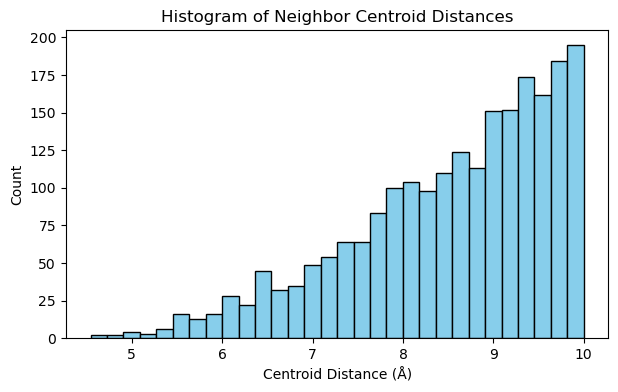

In [18]:
import matplotlib.pyplot as plt

# Get the list of distances
distances = list(neighbor_distances.values())

plt.figure(figsize=(7,4))
plt.hist(distances, bins=30, color='skyblue', edgecolor='k')
plt.xlabel('Centroid Distance (Å)')
plt.ylabel('Count')
plt.title('Histogram of Neighbor Centroid Distances')
plt.show()

# Verify blocking molecules

Immediately creates a pyglet window for users to visually verify blocking.

In [ ]:
# PROBLEM: Molecule does not consider itself when blocking neighbors
from utils.blocking_algo import view_molecule

mol_id = 10 # molecule ID to visualize
view_molecule(mol_id, e_centroids, mol_meshes, neighbor_candidates, 
              neighbor_pairs, view_unpaired_mols=False, distinct_color=True)

Neighbor pairs for molecule 10: [125, 418, 623]
Non-paired neighbors are: []
----------------------------------------
You have selected: []
----------------------------------------
You are now viewing molecules [10, 125, 418, 623]


2025-10-13 12:28:24.139 python[13842:29056118] +[IMKClient subclass]: chose IMKClient_Modern
2025-10-13 12:28:24.199 python[13842:29056118] +[IMKInputSession subclass]: chose IMKInputSession_Modern


: 

In [24]:
from utils.blocking_algo import get_neighbor_candidates

neighbor_candidates = get_neighbor_candidates(box_dimensions, centroids, k=1, threshold_distance=30)

In [25]:
len(neighbor_candidates)

736

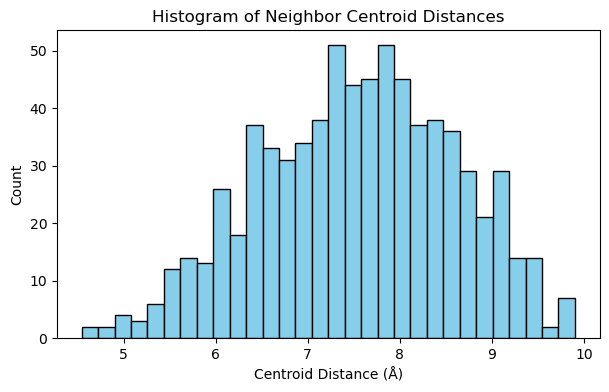

In [26]:
# Calculate and store distances between neighbor candidate pairs using centroids
neighbor_distances = {}

for i, j in neighbor_candidates:
    c_i = centroids[i]
    c_j = centroids[j]
    dist = mh.mic_distance(c_i, c_j, box_dimensions)
    neighbor_distances[(i, j)] = dist

# Get the list of distances
distances = list(neighbor_distances.values())

plt.figure(figsize=(7,4))
plt.hist(distances, bins=30, color='skyblue', edgecolor='k')
plt.xlabel('Centroid Distance (Å)')
plt.ylabel('Count')
plt.title('Histogram of Neighbor Centroid Distances')
plt.show()